In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

from subprocess import check_output
print(check_output(["ls", "../input"]).decode("utf8"))

# Any results you write to the current directory are saved as output.

pima-indians-diabetes.data.csv



In [2]:
filename = '../input/pima-indians-diabetes.data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
df=pd.read_csv("../input/"+filename,names=names)
skew=df.skew()

In [3]:
print(skew)
#for normally distributed data skewness should be close to zero. If skewness>0 then
#it means that there is more weight on the left tail of the distribution and if skewness<0 then it means that
# there is more weight on the right tail of the distribution

preg     0.901674
plas     0.173754
pres    -1.843608
skin     0.109372
test     2.272251
mass    -0.428982
pedi     1.919911
age      1.129597
class    0.635017
dtype: float64


In [4]:
df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


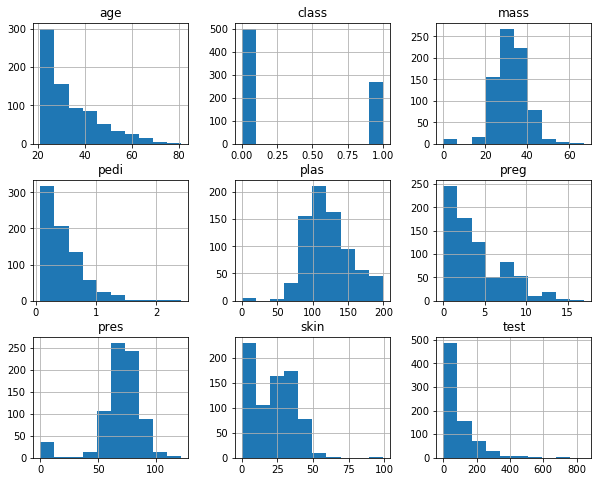

In [6]:
df.hist(figsize=(10,8))
plt.show()

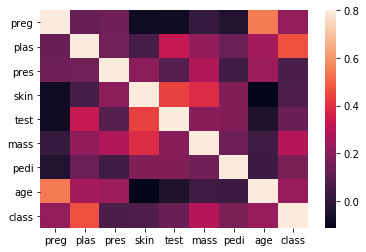

In [7]:
corr=df.corr()
sns.heatmap(corr,vmax=0.8)

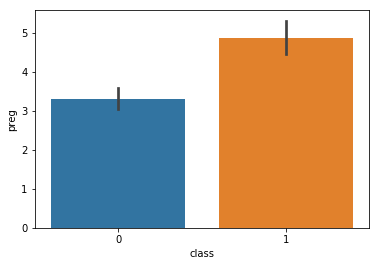

In [8]:
#lets see the relationship between our independent variables and dependent variable(Class)
sns.barplot("class","preg",data=df)

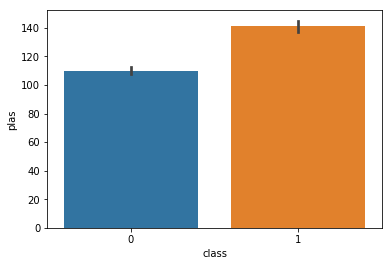

In [9]:
sns.barplot("class","plas",data=df)

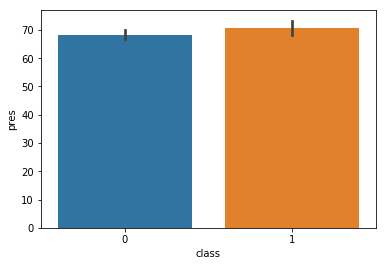

In [10]:
sns.barplot("class","pres",data=df)

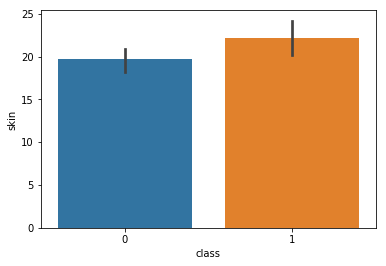

In [11]:
sns.barplot("class","skin",data=df)

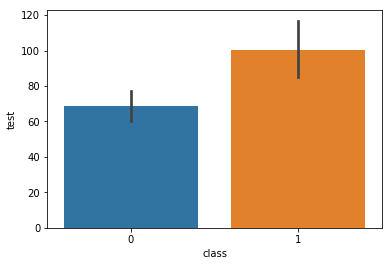

In [12]:
sns.barplot("class","test",data=df)

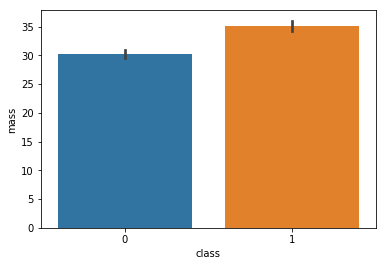

In [13]:
sns.barplot("class","mass",data=df)

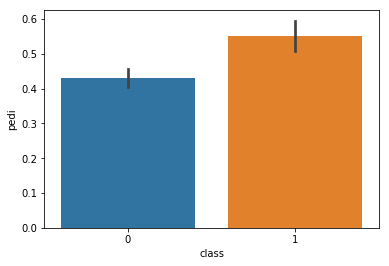

In [14]:
sns.barplot("class","pedi",data=df)

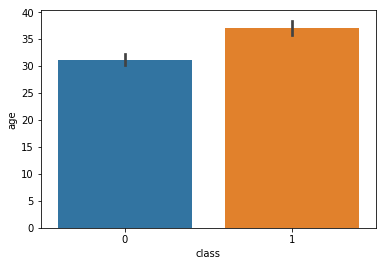

In [15]:
sns.barplot("class","age",data=df)

In [16]:

X=df.iloc[:,0:8]
y=df.iloc[:,8]
X.head()



,preg,plas,pres,skin,test,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [17]:
#Spliiting our dataset into training and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)


In [18]:
#Applying Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [19]:
#Ppplying logistic Regression
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(random_state=0)
classifier.fit(X_train,y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=0, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

In [20]:
#Calculating Y_pred
y_pred=classifier.predict(X_test)

In [21]:
#Forming a confusion matrix to check our accuracy
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[98  9]
 [18 29]]


In [22]:
acc=(98+29)/(98+29+18+9)
print(acc)
#We got an accuracy of 82.46%

0.8246753246753247
